In [1]:
!pip install -q xgboost==3.0.2 scikit-learn==1.6.1 joblib==1.5.3

In [2]:
import sklearn
import xgboost
import joblib

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Joblib:", joblib.__version__)

scikit-learn: 1.6.1
XGBoost: 3.0.2
Joblib: 1.5.3


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Path to dataset files: /kaggle/input/credit-risk-dataset


In [5]:
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [7]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [8]:
df['loan_status'].unique()
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


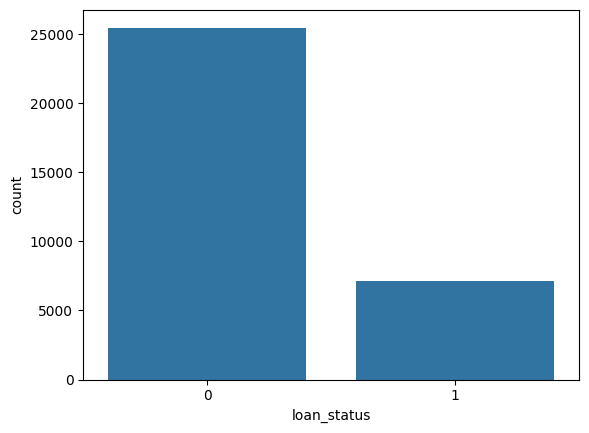

In [9]:
sns.countplot(x='loan_status', data=df)
plt.show()

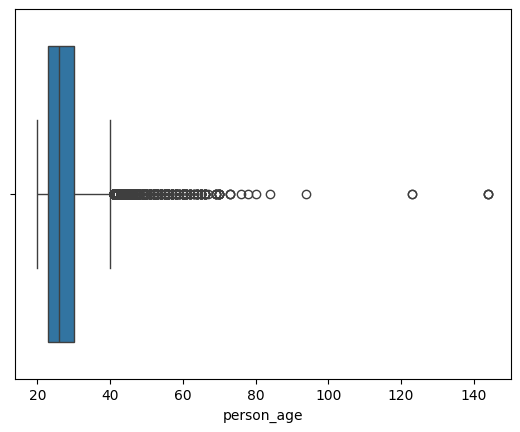

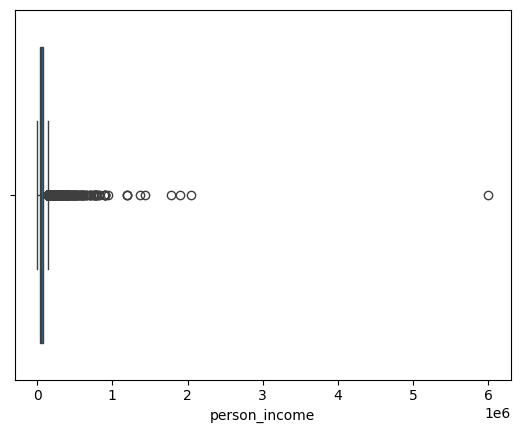

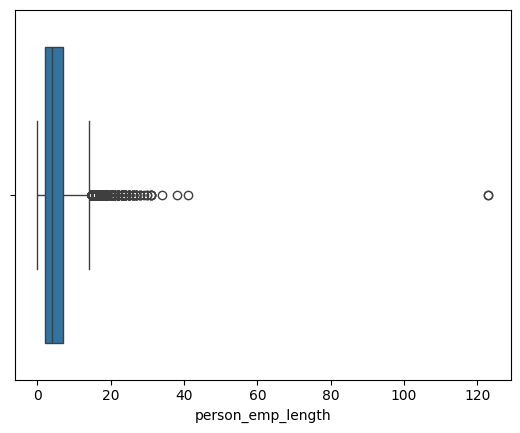

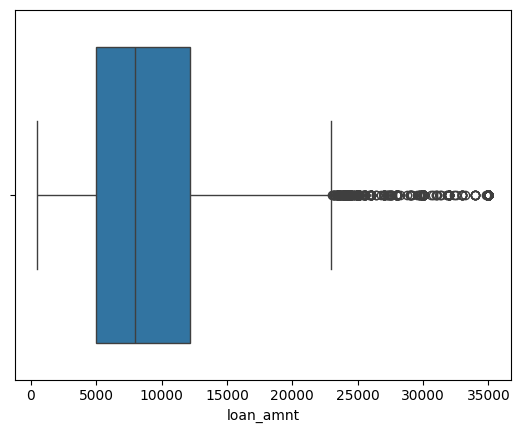

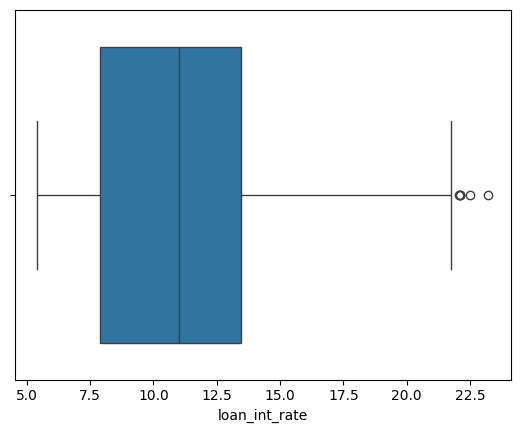

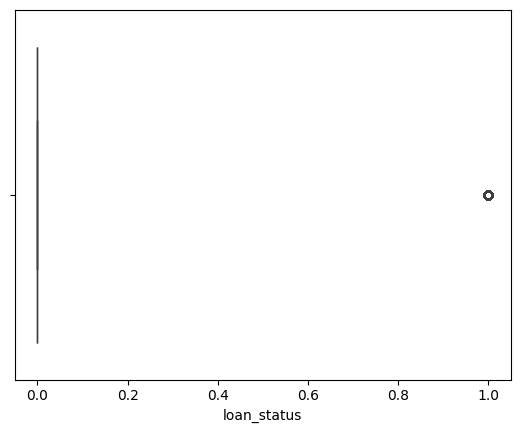

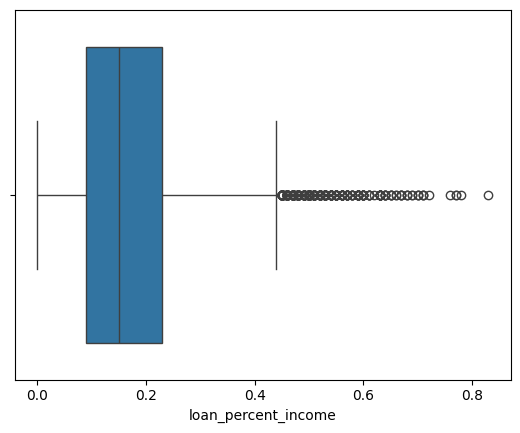

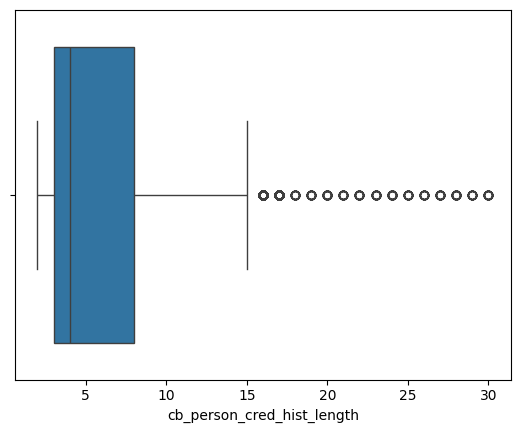

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()

In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


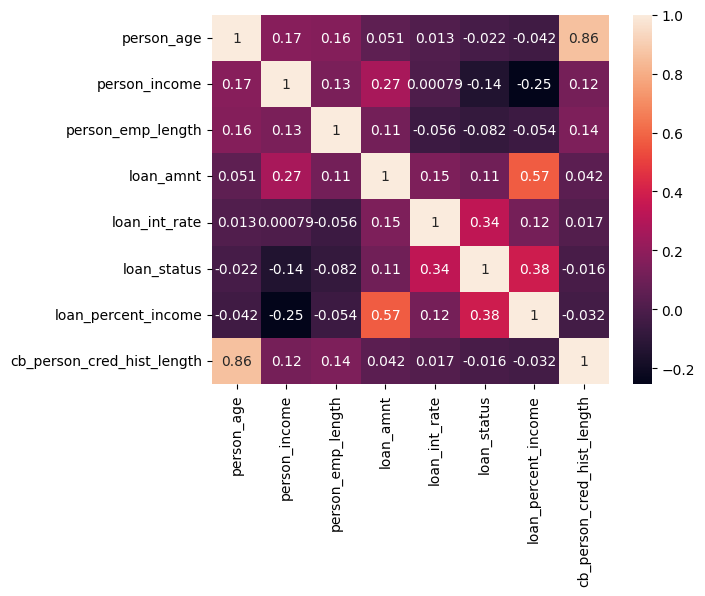

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [13]:
df_copy=df.copy()
print(f"Original Rows :{df_copy.shape[0]}")
df_copy.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates:{df_copy.shape[0]}")

df_copy = df_copy[df_copy['person_age']>=18]
df_copy = df_copy[df_copy['person_age']<=100]
df_copy = df_copy[df_copy['person_emp_length']<=df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length']<=60]

df_copy=df_copy[df_copy['loan_amnt']>0]

print("loan interest rate range from(min: 5.42 and max:23.22)")

Original Rows :32581
Rows after removing duplicates:32416
loan interest rate range from(min: 5.42 and max:23.22)


In [14]:
X=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
numeric_cols=['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
categorical_cols=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']



In [17]:
neg,pos=np.bincount(y_train)
scale_weights=neg/pos

In [18]:
scale_weights

np.float64(3.6092122098336685)

In [19]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

preprocessor_lr=ColumnTransformer(
    transformers=[
        ('num',Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())]),numeric_cols),
        ('cat',Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))]),categorical_cols)
    ]
)


In [20]:
from sklearn.metrics import roc_auc_score,classification_report,accuracy_score,precision_score,confusion_matrix,recall_score,f1_score,precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model_name,model,X_train,y_train,X_test,y_test):
  y_pred=model.predict(X_test)
  y_pred_proba=model.predict_proba(X_test)[:,1]

  acc_score=accuracy_score(y_test,y_pred)
  prec_score=precision_score(y_test,y_pred)
  rec_score=recall_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)

  cm=confusion_matrix(y_test,y_pred)
  class_report=classification_report(y_test,y_pred)

  print(f"Accuracy Score: {acc_score}")
  print(f"Precision Score: {prec_score}")
  print(f"Recall Score: {rec_score}")
  print(f"F1 Score: {f1}")
  print("Confusion Matrix:")
  print(cm)
  print(f"{model_name} Classification Report:")
  print(class_report)

  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  sns.heatmap(cm,annot=True,fmt="d", cmap='Blues')
  plt.title(f"{model_name} Confusion Matrix")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")

  plt.subplot(1, 2, 2)
  precision,recalls,thresholds=precision_recall_curve(y_test,y_pred_proba)
  plt.plot(thresholds,precision[:-1],label="Precision")
  plt.plot(thresholds,recalls[:-1],label="Recall")
  plt.xlabel("Threshold")
  plt.ylabel("Score")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

In [21]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scoring={'roc_auc':'roc_auc','accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1'}

In [22]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42))
])
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [23]:
from xgboost import XGBClassifier
xgb_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.1,scale_pos_weight=scale_weights,random_state=42,n_jobs=-1))
])
xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy=...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [24]:
from sklearn.model_selection import cross_validate

for cv_name,pipe in[('Logistic Regression',lr_cv_pipeline),
                    ('XGBoost',xgb_cv_pipeline)]:
                   cv_results= cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
                   print(f"--- {cv_name} ---")
                   print(f"ROC AUC: {cv_results['test_roc_auc'].mean():.3f} +- {cv_results['test_roc_auc'].std():.3f}")
                   print(f"Accuracy: {cv_results['test_accuracy'].mean():.3f} +- {cv_results['test_accuracy'].std():.3f}")
                   print(f"Precision: {cv_results['test_precision'].mean():.3f} +- {cv_results['test_precision'].std():.3f}")
                   print(f"Recall: {cv_results['test_recall'].mean():.3f} +- {cv_results['test_recall'].std():.3f}")
                   print(f"F1-Score: {cv_results['test_f1'].mean():.3f} +- {cv_results['test_f1'].std():.3f}")
                   print("")

--- Logistic Regression ---
ROC AUC: 0.874 +- 0.008
Accuracy: 0.815 +- 0.006
Precision: 0.551 +- 0.009
Recall: 0.780 +- 0.015
F1-Score: 0.646 +- 0.011

--- XGBoost ---
ROC AUC: 0.947 +- 0.005
Accuracy: 0.918 +- 0.005
Precision: 0.820 +- 0.011
Recall: 0.800 +- 0.018
F1-Score: 0.810 +- 0.013



In [25]:
cv_results

{'fit_time': array([2.44106054, 2.32239389, 1.98582149, 2.52074528, 2.36348748]),
 'score_time': array([0.25666785, 0.42393541, 0.18849587, 0.35986137, 0.56056929]),
 'test_roc_auc': array([0.9457323 , 0.94172572, 0.94688934, 0.95702659, 0.94249233]),
 'test_accuracy': array([0.91752577, 0.91831879, 0.91770771, 0.92762245, 0.91116399]),
 'test_precision': array([0.81860902, 0.82804995, 0.81937912, 0.83226983, 0.80130597]),
 'test_recall': array([0.79616088, 0.78721461, 0.79616088, 0.8345521 , 0.78519196]),
 'test_f1': array([0.80722892, 0.8071161 , 0.80760315, 0.8334094 , 0.79316713])}

In [26]:
from sklearn.linear_model import LogisticRegression
baseline_model=Pipeline([
    ('Preprocessor',preprocessor_lr),
    ('Classifier',LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42))
])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('Classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

Accuracy Score: 0.8103092783505155
Precision Score: 0.5366876310272537
Recall Score: 0.7664670658682635
F1 Score: 0.6313193588162762
Confusion Matrix:
[[4085  884]
 [ 312 1024]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4969
           1       0.54      0.77      0.63      1336

    accuracy                           0.81      6305
   macro avg       0.73      0.79      0.75      6305
weighted avg       0.85      0.81      0.82      6305



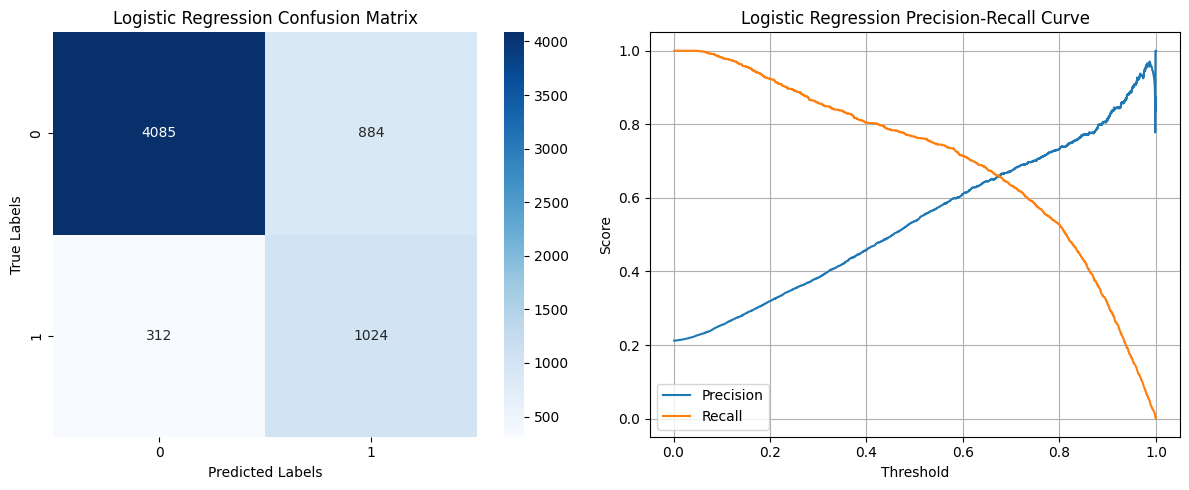

In [27]:
evaluate_model("Logistic Regression",baseline_model,X_train,y_train,X_test,y_test)

In [28]:
xg_model=Pipeline([
    ('Preprocessor',preprocessor_lr),
    ('Classifier',XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.1,scale_pos_weight=scale_weights,random_state=42,n_jobs=-1))
])
xg_model.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy=...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

Accuracy Score: 0.8103092783505155
Precision Score: 0.5366876310272537
Recall Score: 0.7664670658682635
F1 Score: 0.6313193588162762
Confusion Matrix:
[[4085  884]
 [ 312 1024]]
Baseline Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4969
           1       0.54      0.77      0.63      1336

    accuracy                           0.81      6305
   macro avg       0.73      0.79      0.75      6305
weighted avg       0.85      0.81      0.82      6305



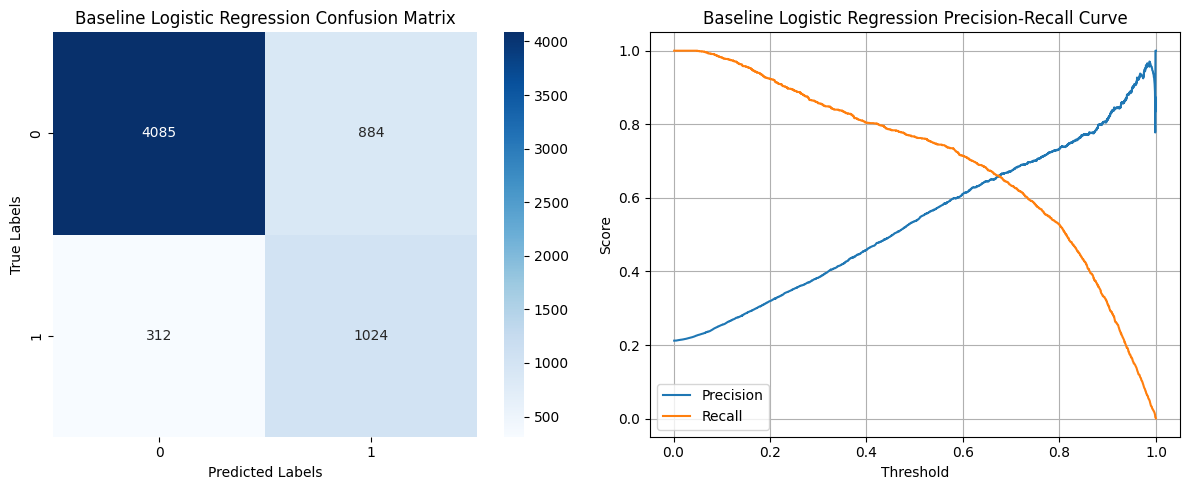

In [29]:
evaluate_model("Baseline Logistic Regression",baseline_model,X_train,y_train,X_test,y_test)

Now, let's evaluate the XGBoost model to compare its performance against the baseline.

Accuracy Score: 0.9192704203013481
Precision Score: 0.8207913110938713
Recall Score: 0.7919161676646707
F1 Score: 0.8060952380952381
Confusion Matrix:
[[4738  231]
 [ 278 1058]]
XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4969
           1       0.82      0.79      0.81      1336

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



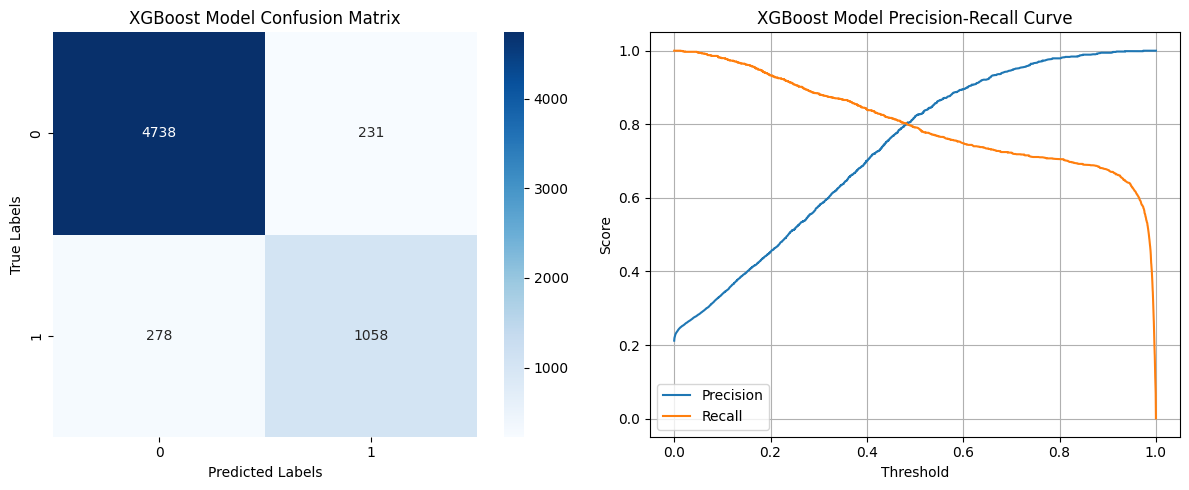

In [30]:
evaluate_model("XGBoost Model",xg_model,X_train,y_train,X_test,y_test)

In [31]:
from numpy.random import randint
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats # Import scipy.stats for defining distributions

param_grid={
    "classifier__n_estimators":stats.randint(150,601), # (low, high+1) for integers
    "classifier__max_depth":stats.randint(3,10), # (low, high+1) for integers
    "classifier__learning_rate":stats.uniform(0.01,0.49), # (loc, scale) where scale = high - low
    "classifier__subsample":stats.uniform(0.4,0.2), # Assuming range 0.4 to 0.6
    "classifier__colsample_bytree":stats.uniform(0.4,0.2), # Assuming range 0.4 to 0.6
    "classifier__min_child_weight":stats.randint(1,11), # (low, high+1) for integers
    "classifier__gamma":stats.randint(0,6) # (low, high+1) for integers

}


In [32]:
RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=50,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
# random_search.fit(X_train,y_train)   here??

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('Preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income'...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a078a54ad50>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a078bfd6510>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a078a54a990>},
                   scoring='average_precision', verbose=1)

Accuracy Score: 0.9192704203013481
Precision Score: 0.8207913110938713
Recall Score: 0.7919161676646707
F1 Score: 0.8060952380952381
Confusion Matrix:
[[4738  231]
 [ 278 1058]]
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4969
           1       0.82      0.79      0.81      1336

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



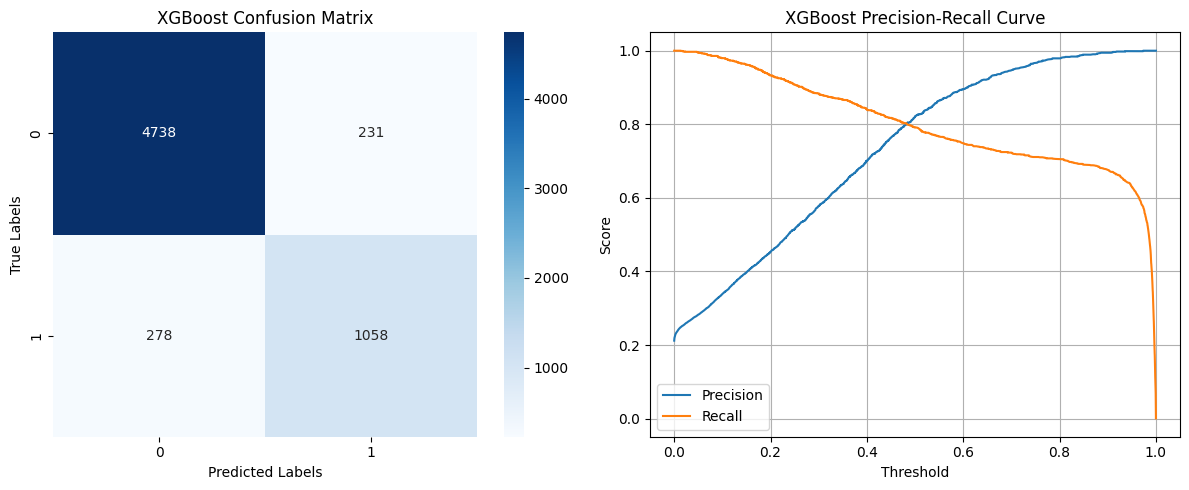

In [33]:
proba=xg_model.predict_proba(X_test)[:,1]
precision,recalls,thresholds=precision_recall_curve(y_test,proba)
f1=2*(precision*recalls)/(precision+recalls+1e-9)
best_f1_idx=np.argmax(f1)
best_threshold=thresholds[best_f1_idx]
evaluate_model("XGBoost",xg_model,X_train,y_train,X_test,y_test)


In [36]:
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
best_model=random_search.best_estimator_
calibrated_model=CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)
calibrated_model.fit(X_train,y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('Preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(ste...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.07305986638598476),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=7,
                                                                max_leaves=None,
                                                                min_child_weight=3,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=591,
                                                                n_jobs=-1,
                                                                num_parallel_tree=None, ...))]))

In [37]:
uncalibrated=xg_model.predict_proba(X_test)[:,1]
calibrated=calibrated_model.predict_proba(X_test)[:,1]
calibrated

array([0.01267967, 0.01273229, 0.01245633, ..., 0.01648972, 0.01241663,
       0.94986102])

In [38]:
actual_uncal,predicted_uncal=calibration_curve(y_test,uncalibrated,n_bins=10)
actual_cal,predicted_cal=calibration_curve(y_test,calibrated,n_bins=10)

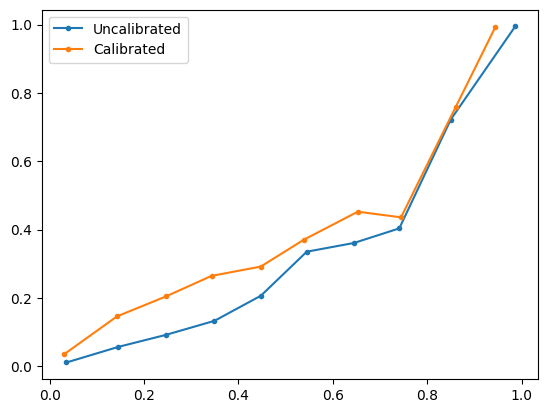

In [39]:
plt.plot(
    predicted_uncal,
    actual_uncal,
    marker='.',
    label="Uncalibrated"
)
plt.plot(
    predicted_cal,
    actual_cal,
    marker='.',
    label="Calibrated"
)

plt.legend()

In [40]:
pip install shap

In [41]:
xgb_classifier=xg_model.named_steps['Classifier']

In [42]:
x_test_transformed=xg_model.named_steps['Preprocessor'].transform(X_test)

In [43]:
feature_names=xg_model.named_steps['Preprocessor'].get_feature_names_out()

In [44]:
x_test_df=pd.DataFrame(x_test_transformed,columns=feature_names)
x_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,-0.603869,0.063757,0.058898,-0.341935,-1.158038,-0.563498,-0.941386,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.765071,1.537646,-0.436677,-0.736783,-0.126415,-1.315839,-0.941386,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.765071,-0.783612,0.058898,-0.420905,0.268605,1.129268,-0.448882,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.120264,0.984965,1.545624,-0.420905,-1.396356,-1.033711,0.289874,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.363342,0.432285,0.554473,-0.768371,-0.697725,-1.127754,-0.202630,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,-0.603869,0.155945,0.306686,0.842611,0.219635,0.282885,-0.448882,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6301,-0.603869,0.432285,-1.180039,-0.262965,0.637508,-0.751584,-0.941386,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,0.846947,0.671780,0.058898,2.264065,-1.158038,0.565013,1.028629,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,0.685746,0.800739,-0.684464,-0.642020,-0.097034,-1.127754,0.289874,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [45]:
from sklearn.model_selection import train_test_split
import shap
explainer=shap.TreeExplainer(xgb_classifier)

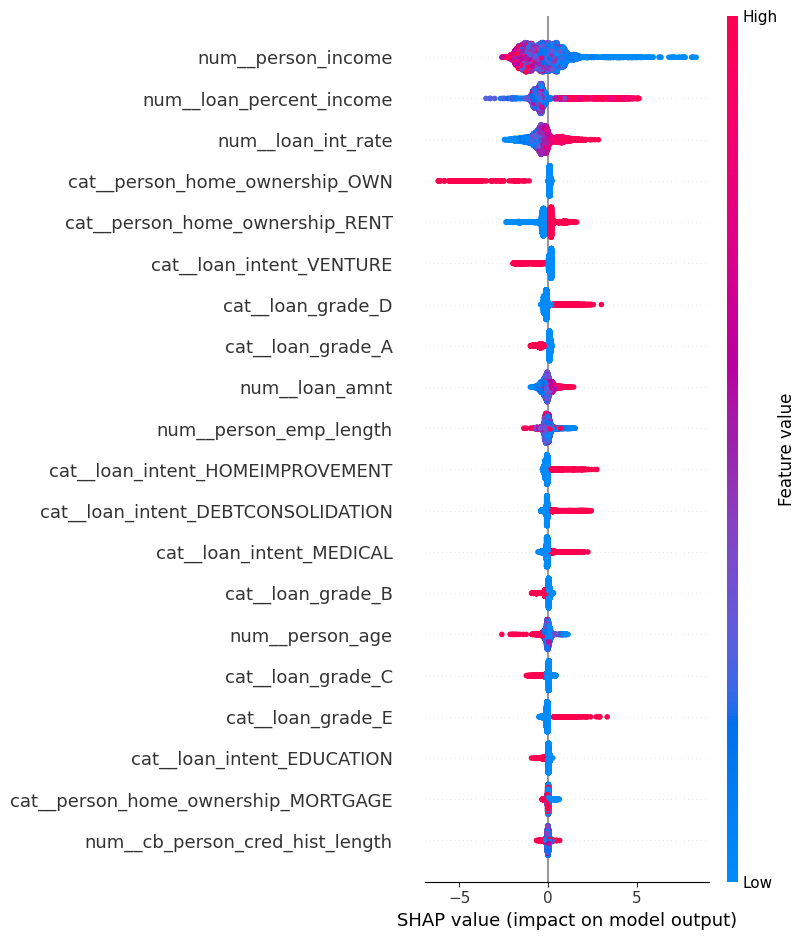

In [46]:
shap_values = explainer.shap_values(x_test_df)
shap.summary_plot(shap_values,x_test_df)

In [47]:
x_test_df.iloc[5]

,5
num__person_age,-0.926273
num__person_income,-0.304623
num__person_emp_length,-0.932252
num__loan_amnt,-1.021074
num__loan_int_rate,-0.831575
num__loan_percent_income,-1.033711
num__cb_person_cred_hist_length,-0.448882
cat__person_home_ownership_MORTGAGE,0.000000
cat__person_home_ownership_OTHER,0.000000
cat__person_home_ownership_OWN,0.000000


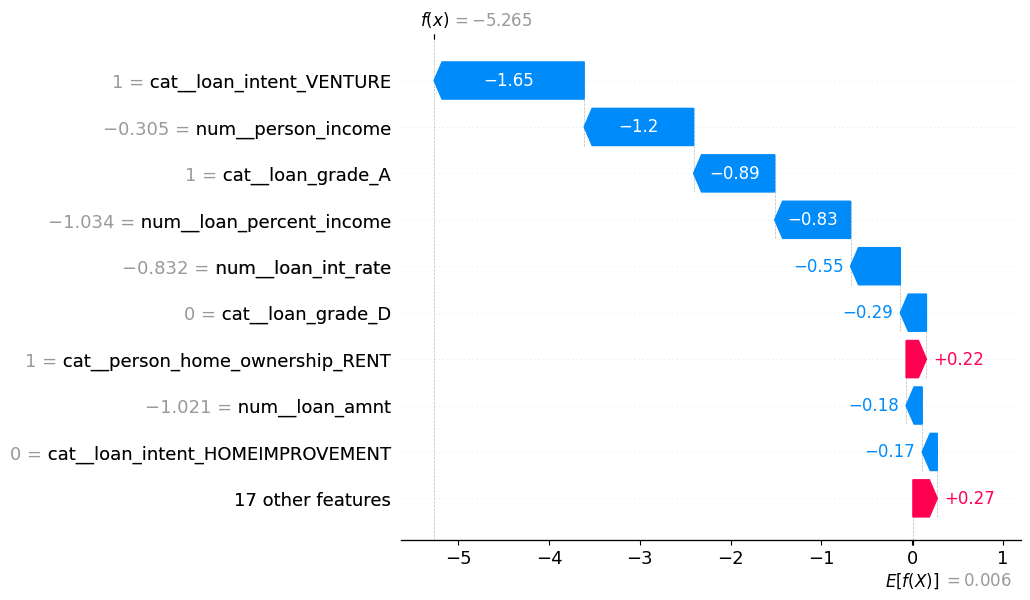

In [48]:
row_index=5

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index],
        base_values=explainer.expected_value,
        data=x_test_df.iloc[row_index],
        feature_names=x_test_df.columns.tolist()
)
    )

In [49]:
import scipy.stats as stats # Required for param_grid distributions
from sklearn.model_selection import RandomizedSearchCV # Ensure it's imported

# Corrected param_grid with 'Classifier__' (uppercase 'C')
param_grid={
    "Classifier__n_estimators":stats.randint(150,601), # (low, high+1) for integers
    "Classifier__max_depth":stats.randint(3,10), # (low, high+1) for integers
    "Classifier__learning_rate":stats.uniform(0.01,0.49), # (loc, scale) where scale = high - low
    "Classifier__subsample":stats.uniform(0.4,0.2), # Assuming range 0.4 to 0.6
    "Classifier__colsample_bytree":stats.uniform(0.4,0.2), # Assuming range 0.4 to 0.6
    "Classifier__min_child_weight":stats.randint(1,11), # (low, high+1) for integers
    "Classifier__gamma":stats.randint(0,6) # (low, high+1) for integers
}

# Instantiate and fit RandomizedSearchCV
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=50,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train,y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('Preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income'...
                                        'Classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a076120a990>,
                                        'Classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a076125f750>,
                                        'Classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a0760ea97b0>},
                   scoring='average_precision', verbose=1)

In [50]:
y_pred = random_search.predict(X_test)
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred
# result_df['predicted_proba'] = y_pred_proba
# result_df['predicted_class'] = y_pred_proba

In [51]:
result_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
8400,24,69996,RENT,5.0,VENTURE,A,7500,7.49,0.11,N,2,0,0
5698,23,150000,RENT,3.0,VENTURE,B,5000,10.65,0.03,N,2,0,0
15233,23,24000,OWN,5.0,EDUCATION,B,7000,11.86,0.29,N,4,0,0
28674,27,120000,MORTGAGE,11.0,PERSONAL,A,7000,6.76,0.06,N,7,0,0
26437,30,90000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,4800,8.90,0.05,N,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17341,24,75000,RENT,6.0,HOMEIMPROVEMENT,B,15000,11.71,0.20,N,4,0,0
13239,24,90000,MORTGAGE,0.0,DEBTCONSOLIDATION,C,8000,12.99,0.09,N,2,0,0
26469,33,103000,MORTGAGE,5.0,EDUCATION,A,24000,7.49,0.23,N,10,0,0
26680,32,110000,MORTGAGE,2.0,VENTURE,B,5600,10.74,0.05,N,7,0,0


In [52]:
false_positive = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]
false_negative = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [53]:
print("False Positives:")
print(len(false_positive))

print("\nFalse Negatives:")
print(len(false_negative))

False Positives:
299

False Negatives:
277


In [56]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")
joblib.dump(best_threshold, "best_threshold.pkl")

print("Model saved successfully!")

Model saved successfully!


In [55]:
from sklearn.metrics import precision_recall_curve
import numpy as np

calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, calibrated_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
print("Best Threshold:", best_threshold)

Best Threshold: 0.5446872848492282


#### Ensuring `random_search` is fitted

Although `random_search` was previously defined and fitted, the `AttributeError` indicates that its `best_estimator_` attribute is not available. This can happen if the kernel state was reset or the fitting process was interrupted. The following cell will re-initialize and re-fit `random_search` to ensure it's in the correct state for subsequent operations.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats # Ensure scipy.stats is imported for param_grid

# Re-define param_grid if it's not in scope (from cell LR_kBZiA7oJM)
# This helps ensure all dependencies are met for re-fitting
# It's assumed X_train, y_train, xg_model, cv are already defined from previous cells.
param_grid = {
    "Classifier__n_estimators": stats.randint(150, 601),
    "Classifier__max_depth": stats.randint(3, 10),
    "Classifier__learning_rate": stats.uniform(0.01, 0.49),
    "Classifier__subsample": stats.uniform(0.4, 0.2),
    "Classifier__colsample_bytree": stats.uniform(0.4, 0.2),
    "Classifier__min_child_weight": stats.randint(1, 11),
    "Classifier__gamma": stats.randint(0, 6)
}

# Re-instantiate and fit RandomizedSearchCV
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=50,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
print("Re-fitting random_search...")
random_search.fit(X_train, y_train)
print("random_search has been successfully re-fitted.")

Re-fitting random_search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
random_search has been successfully re-fitted.
